<a href="https://colab.research.google.com/github/pratyushsingh9870-arch/ML_lab/blob/main/lab_seven.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== BAGGING CLASSIFIER =====
Accuracy: 0.956140350877193

Confusion Matrix:
 [[40  3]
 [ 2 69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



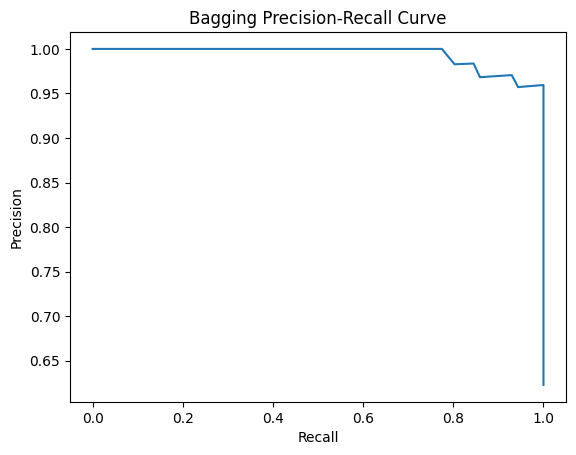


===== RANDOM FOREST =====
Accuracy: 0.9649122807017544

Confusion Matrix:
 [[40  3]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



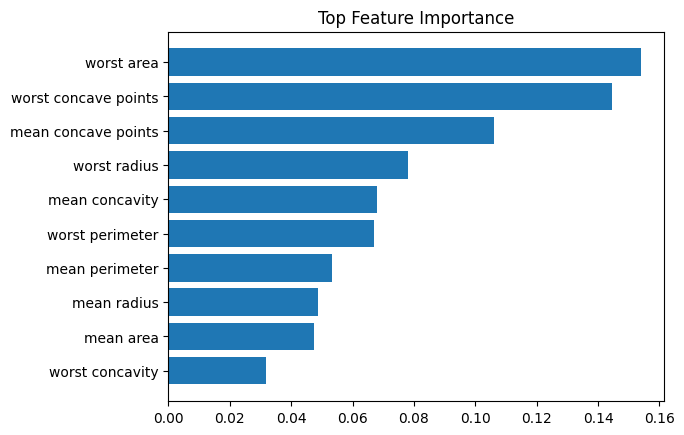


===== ADABOOST =====
Accuracy: 0.9649122807017544

Confusion Matrix:
 [[40  3]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


===== MODEL COMPARISON =====


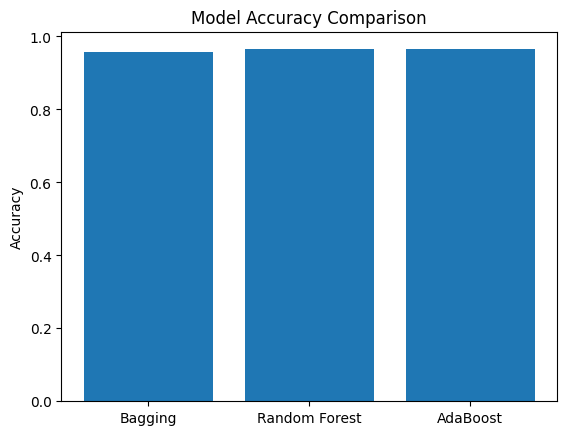

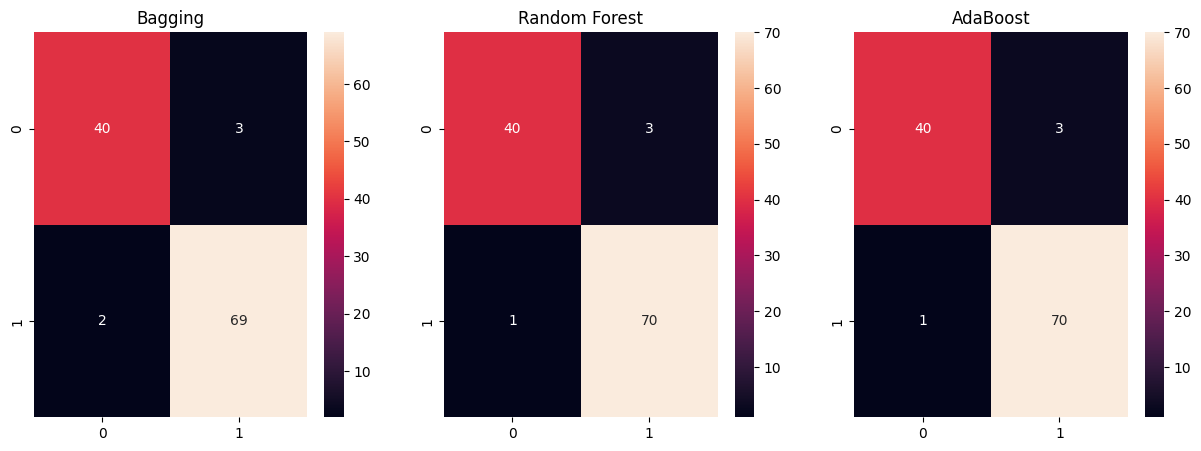


Final Accuracy:
Bagging: 0.956140350877193
Random Forest: 0.9649122807017544
AdaBoost: 0.9649122807017544

Best Model: Random Forest


In [1]:
# ============================
# 🔹 IMPORT LIBRARIES
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

# ============================
# 🔹 LOAD DATASET (AUTO)
# ============================
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============================
# 🔹 EXPERIMENT 1: BAGGING
# ============================
print("\n===== BAGGING CLASSIFIER =====")

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))

# Precision-Recall Curve
y_prob_bag = bagging.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_bag)

plt.plot(recall, precision)
plt.title("Bagging Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ============================
# 🔹 EXPERIMENT 2: RANDOM FOREST
# ============================
print("\n===== RANDOM FOREST =====")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top Feature Importance")
plt.show()


# ============================
# 🔹 EXPERIMENT 3: ADABOOST
# ============================
print("\n===== ADABOOST =====")

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))


# ============================
# 🔹 EXPERIMENT 4: COMPARISON
# ============================
print("\n===== MODEL COMPARISON =====")

acc_bag = accuracy_score(y_test, y_pred_bag)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_ada = accuracy_score(y_test, y_pred_ada)

models = ['Bagging', 'Random Forest', 'AdaBoost']
accuracies = [acc_bag, acc_rf, acc_ada]

# Bar Chart
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Bagging")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Random Forest")

sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', ax=axes[2])
axes[2].set_title("AdaBoost")

plt.show()

# ============================
# 🔹 FINAL RESULT
# ============================
print("\nFinal Accuracy:")
print("Bagging:", acc_bag)
print("Random Forest:", acc_rf)
print("AdaBoost:", acc_ada)

best_model = models[np.argmax(accuracies)]
print("\nBest Model:", best_model)